<a href="https://colab.research.google.com/github/musaadamukhs/Multi-Channel-Marketing-MLR/blob/main/multiple_regression_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

--- Dataset Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 572 entries, 0 to 571
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   TV            572 non-null    int64  
 1   Radio         572 non-null    float64
 2   Social Media  572 non-null    float64
 3   Influencer    572 non-null    object 
 4   Sales         572 non-null    float64
dtypes: float64(3), int64(1), object(1)
memory usage: 22.5+ KB
None

--- Descriptive Statistics ---
               TV       Radio  Social Media       Sales
count  572.000000  572.000000    572.000000  572.000000
mean     0.938811   17.520616      3.333803  189.296908
std      0.799363    9.290933      2.238378   89.871581
min      0.000000    0.109106      0.000031   33.509810
25%      0.000000   10.699556      1.585549  118.718722
50%      1.000000   17.149517      3.150111  184.005362
75%      2.000000   24.606396      4.730408  264.500118
max      2.000000   42.271

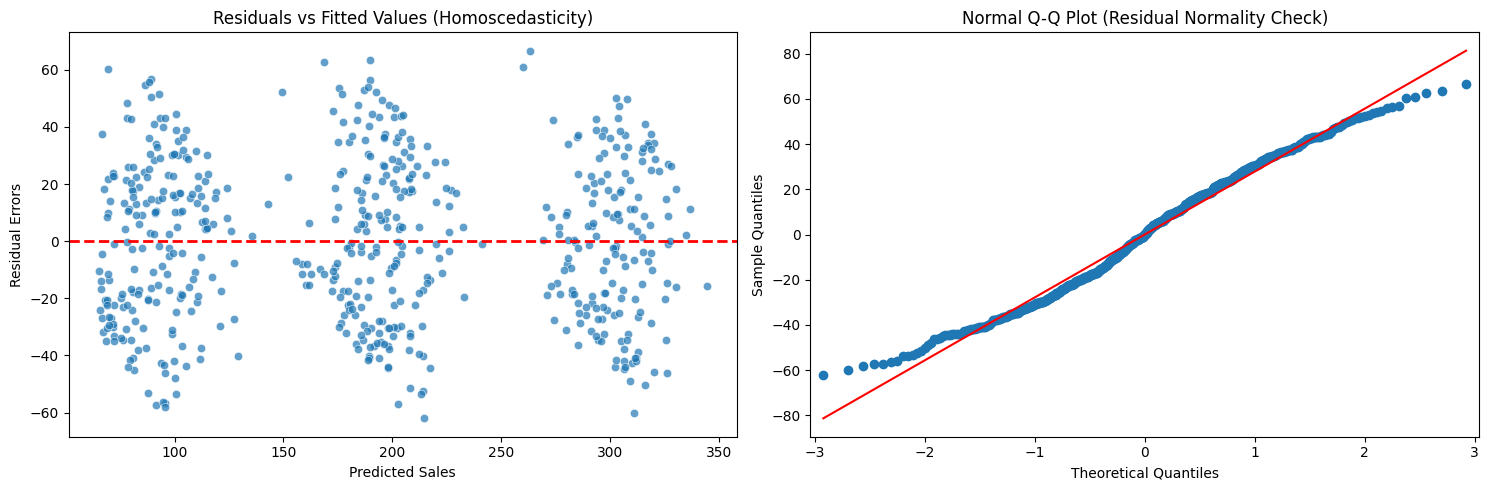

In [3]:
# ==============================================================================
# STEP 1: LOAD THE DATASET & INITIAL EDA
# ==============================================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
from scipy import stats

# Load data
df = pd.read_csv("marketing_sales_data.csv")

# Clean missing values to avoid errors during VIF or OLS estimation
df = df.dropna()

# Convert 'TV' column to numerical representation since it's an ordinal categorical variable
tv_mapping = {'Low': 0, 'Medium': 1, 'High': 2}
df['TV'] = df['TV'].map(tv_mapping)

print("--- Dataset Info ---")
print(df.info())
print("\n--- Descriptive Statistics ---")
print(df.describe())

# ==============================================================================
# STEP 2: MULTICOLLINEARITY CHECK (CORRELATION & VIF)
# ==============================================================================
# 1. Generate Correlation Matrix
features = df[['TV', 'Radio', 'Social Media']]
correlation_matrix = features.corr()
print("\n--- Feature Correlation Matrix ---")
print(correlation_matrix)

# 2. Calculate Variance Inflation Factor (VIF)
vif_data = pd.DataFrame()
vif_data["Feature"] = features.columns

# Adding a constant is mathematically mandatory for a valid VIF calculation
features_with_const = sm.add_constant(features)
vif_data["VIF"] = [variance_inflation_factor(features_with_const.values, i) for i in range(1, features_with_const.shape[1])]

print("\n--- Variance Inflation Factor (VIF) ---")
print(vif_data)

# ==============================================================================
# STEP 3 & 4: BUILD THE OLS MODEL & EVALUATE PERFORMANCE
# ==============================================================================
X = df[['TV', 'Radio', 'Social Media']]
y = df['Sales']

# Add constant intercept to the design matrix
X_model = sm.add_constant(X)

# Fit Multivariate Ordinary Least Squares Regression
mlr_model = sm.OLS(y, X_model).fit()
print("\n--- OLS Regression Results Summary ---")
print(mlr_model.summary())

# ==============================================================================
# STEP 5: RESIDUAL DIAGNOSTICS VISUALIZATION
# ==============================================================================
fitted_values = mlr_model.predict(X_model)
residuals = mlr_model.resid

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Plot 1: Homoscedasticity and Linearity Check
sns.scatterplot(x=fitted_values, y=residuals, ax=axes[0], alpha=0.7)
axes[0].axhline(y=0, color='red', linestyle='--', linewidth=2)
axes[0].set_title('Residuals vs Fitted Values (Homoscedasticity)')
axes[0].set_xlabel('Predicted Sales')
axes[0].set_ylabel('Residual Errors')

# Plot 2: Normality Check
sm.qqplot(residuals, line='s', ax=axes[1])
axes[1].set_title('Normal Q-Q Plot (Residual Normality Check)')

plt.tight_layout()
plt.show()